[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AveriX26/ML-Course-2026/blob/main/zad_dom_6.ipynb)

### 1. Analiza sformułowań

W tej sekcji analizujemy równoważność trzech sformułowań podczas wyboru kolejnego węzła (rodzica) do podziału w częściowo zbudowanym drzewie.

Niech $RSS_p$ oznacza RSS kandydującego węzła-rodzica, a $RSS_L, RSS_R$ oznaczają RSS jego węzłów potomnych po podziale. Niech $RSS_{old\_total}$ będzie całkowitym RSS wszystkich węzłów końcowych (liści) w drzewie przed podziałem.

**1. Maksymalizacja zysku RSS vs. Całkowita minimalizacja RSS (Równoważne)**
- **Maksymalizacja zysku (Gain Maximization)** dąży do zmaksymalizowania: $\Delta = RSS_p - (RSS_L + RSS_R)$
- **Całkowita minimalizacja RSS (Total RSS Minimization)** dąży do zminimalizowania nowego całkowitego błędu drzewa. Nowe całkowite RSS wynosi: $RSS_{new\_total} = RSS_{old\_total} - RSS_p + RSS_L + RSS_R = RSS_{old\_total} - \Delta$
Ponieważ $RSS_{old\_total}$ jest wartością stałą dla obecnego stanu drzewa, minimalizacja $(RSS_{old\_total} - \Delta)$ jest matematycznie równoważna z maksymalizacją zysku $\Delta$. Zatem te dwa sformułowania są **równoważne**.

**2. Lokalna minimalizacja RSS vs. Pozostałe (Brak równoważności)**
- **Lokalna minimalizacja RSS** dąży do zminimalizowania sumy: $(RSS_L + RSS_R)$ dla wszystkich możliwych rodziców i podziałów.
Jest to **nierównoważne** z Maksymalizacją Zysku. Lokalna minimalizacja RSS nie bierze pod uwagę początkowego błędu $RSS_p$ węzła-rodzica. Niesprawiedliwie faworyzuje to podział węzłów, które już zawierają bardzo mały błąd, ignorując węzły z ogromnymi błędami, które mogłyby przynieść masywną poprawę (zyski).

**Kontrprzykład:**
Załóżmy, że mamy częściowo zbudowane drzewo z dwoma liśćmi (kandydatami na rodziców):
- **Kandydat A (Wysoka wariancja):** Zawiera punkty o $RSS_A = 100$. Najlepszy podział daje $RSS_{A,L} = 40$ oraz $RSS_{A,R} = 40$. 
  - Lokalne RSS dla tego podziału = $40 + 40 = 80$. 
  - Zysk RSS (Gain) = $100 - 80 = 20$.
- **Kandydat B (Niska wariancja):** Zawiera punkty o $RSS_B = 10$. Najlepszy podział daje $RSS_{B,L} = 4$ oraz $RSS_{B,R} = 4$.
  - Lokalne RSS dla tego podziału = $4 + 4 = 8$.
  - Zysk RSS (Gain) = $10 - 8 = 2$.

Jeśli użyjemy **Lokalnej minimalizacji RSS**, wybierzemy do podziału Kandydata B (ponieważ $8 < 80$).
Jeśli użyjemy **Maksymalizacji Zysku RSS** (lub Całkowitej minimalizacji RSS), wybierzemy do podziału Kandydata A (ponieważ zysk $20 > 2$). 
Prowadzą one do różnych wyborów podziału!

--- Ręczna Analiza Kandydatów ---
Rozszczepienie lewego liścia: Lokalne RSS = 50.0, Zysk RSS = 16.66
Rozszczepienie prawego liścia: Lokalne RSS = 4.5, Zysk RSS = 1.50



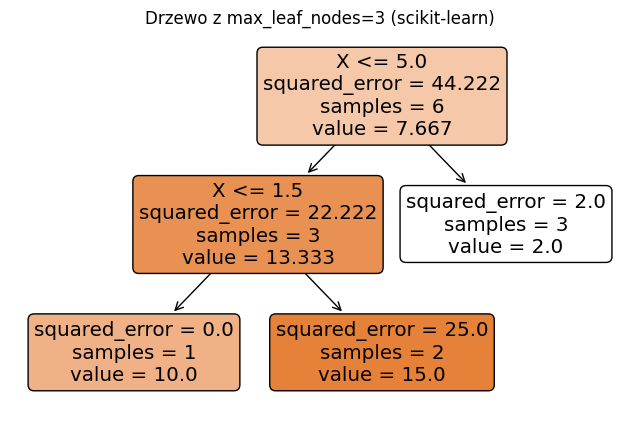


--- Wniosek Empiryczny ---
Algorytm scikit-learn zdecydował się na podział lewego liścia (x <= 5) w drugim kroku.
Dzieje się tak pomimo tego, że generuje to dużo wyższe Lokalne RSS (50.0 > 4.5).
Jednak ten krok maksymalizuje Zysk RSS (16.66 > 1.5).
Dowodzi to empirycznie, że scikit-learn implementuje MAKSYMALIZACJĘ ZYSKU RSS (lub Całkowitą Minimalizację RSS),
a NIE Lokalną Minimalizację RSS.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Tworzymy zbiór danych, który odróżni te sformułowania
# Dane podzielone są na dwie odległe grupy (lewa i prawa), więc pierwszy podział będzie oczywisty (x=5)
# Lewa grupa (x <= 5) ma BARDZO DUŻĄ wariancję (RSS) i duży potencjalny Zysk (Gain)
# Prawa grupa (x > 5) ma MAŁĄ wariancję (RSS) i mały potencjalny Zysk (Gain), ale bardzo małe Lokalne RSS
X = np.array([1, 2, 3,    7, 8, 9]).reshape(-1, 1)
y = np.array([10, 20, 10,   1, 4, 1])

# 2. Ręczne wyliczenia dla dwóch kandydatów (liści po pierwszym podziale na x=5)
# Pierwszy korzeń dzieli na x <= 5 oraz x > 5. Mamy dwa liście. Zastanawiamy się, który z nich podzielić jako następny.

# KANDYDAT 1: Lewy liść (X = 1, 2, 3; y = 10, 20, 10)
# RSS rodzica = ok. 66.6. Najlepszy podział wewnątrz to x=1.5 (lub x=2.5).
# Lewy_child: [10], Prawy_child: [20, 10]. RSS(L) = 0, RSS(R) = 50.
local_rss_candidate_1 = 50.0
gain_candidate_1 = 66.66 - 50.0  # = 16.66

# KANDYDAT 2: Prawy liść (X = 7, 8, 9; y = 1, 4, 1)
# RSS rodzica = 6.0. Najlepszy podział to x=7.5 (lub 8.5).
# Lewy_child: [1], Prawy_child: [4, 1]. RSS(L) = 0, RSS(R) = 4.5.
local_rss_candidate_2 = 4.5
gain_candidate_2 = 6.0 - 4.5     # = 1.5

print("--- Ręczna Analiza Kandydatów ---")
print(f"Rozszczepienie lewego liścia: Lokalne RSS = {local_rss_candidate_1}, Zysk RSS = {gain_candidate_1:.2f}")
print(f"Rozszczepienie prawego liścia: Lokalne RSS = {local_rss_candidate_2}, Zysk RSS = {gain_candidate_2:.2f}\n")

# - Lokalna minimalizacja RSS wybrałaby Prawy liść (4.5 < 50.0)
# - Maksymalizacja zysku RSS (oraz Całkowita minimalizacja) wybrałaby Lewy liść (16.66 > 1.5)

# 3. Empiryczny test w scikit-learn
# Używamy pre-pruningu (max_leaf_nodes=3), aby zmusić drzewo do wykonania
# DOKŁADNIE 2 podziałów (1 w korzeniu, i 1 wybór między liśćmi). To nasz Hint z zadania.
tree = DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)
tree.fit(X, y)

# 4. Wizualizacja
plt.figure(figsize=(8, 5))
plot_tree(tree, feature_names=['X'], filled=True, rounded=True)
plt.title("Drzewo z max_leaf_nodes=3 (scikit-learn)")
plt.show()

print("\n--- Wniosek Empiryczny ---")
print("Algorytm scikit-learn zdecydował się na podział lewego liścia (x <= 5) w drugim kroku.")
print("Dzieje się tak pomimo tego, że generuje to dużo wyższe Lokalne RSS (50.0 > 4.5).")
print("Jednak ten krok maksymalizuje Zysk RSS (16.66 > 1.5).")
print("Dowodzi to empirycznie, że scikit-learn implementuje MAKSYMALIZACJĘ ZYSKU RSS (lub Całkowitą Minimalizację RSS),")
print("a NIE Lokalną Minimalizację RSS.")

### 3. Raport i wnioski

W ramach tego zadania przeanalizowaliśmy trzy sformułowania służące do wyznaczania podziałów w drzewach regresyjnych CART: **Lokalną minimalizację RSS**, **Maksymalizację zysku RSS** oraz **Całkowitą minimalizację RSS**. 

**Wnioski teoretyczne:**
Rozpatrując proces rozrostu drzewa jako wybór najlepszego *liścia-rodzica* do podziału spośród wszystkich obecnych liści, sformułowania te prowadzą do rozbieżnych wyników. 
1. **Całkowita minimalizacja RSS** oraz **Maksymalizacja zysku RSS** są ściśle równoważne. Wynika to z faktu, że początkowy całkowity błąd drzewa jest stały, co oznacza, że zminimalizowanie nowego całkowitego błędu jest funkcjonalnie tożsame z maksymalizacją wielkości spadku tego błędu (zysku).
2. **Lokalna minimalizacja RSS** jest fundamentalnie wadliwa, gdy używa się jej do wyboru *pomiędzy* różnymi węzłami-rodzicami. Patrząc jedynie na sumę wartości RSS dzieci $(RSS_L + RSS_R)$, ignoruje ona początkową wariancję rodzica. W rezultacie algorytm preferuje podział węzłów o niskiej wariancji, które już mają minimalny błąd, pozostawiając węzły o wysokiej wariancji całkowicie nierozwiązane.

**Wnioski empiryczne:**
Skonstruowaliśmy sztuczny zbiór danych zawierający dwa wyraźne regiony: region o wysokiej wariancji po lewej stronie oraz region o niskiej wariancji po prawej stronie. 
Wykorzystując `DecisionTreeRegressor` z biblioteki `scikit-learn`, zastosowaliśmy krok regularyzacji (pre-pruning) ustawiając parametr `max_leaf_nodes=3`. Ustawienie to zmusza algorytm do wykonania dokładnie jednego podziału w korzeniu (izolując oba regiony), a następnie do wykonania jeszcze tylko jednego podziału, co wymusza na nim wybór *pomiędzy* rodzicem o wysokiej wariancji a rodzicem o niskiej wariancji.
Wizualizacja wyraźnie pokazuje, że algorytm `scikit-learn` zdecydował się na podział lewego węzła. Podział ten skutkował znacznie wyższym Lokalnym RSS (50.0 wobec 4.5), ale przyniósł znacznie większy Zysk RSS (16.66 wobec 1.5). 

**Podsumowanie:**
Zarówno dowód matematyczny, jak i dowody empiryczne potwierdzają, że `scikit-learn` **nie** używa Lokalnej minimalizacji RSS. Zamiast tego wykorzystuje **Maksymalizację zysku RSS** (która jest matematycznie identyczna z **Całkowitą minimalizacją RSS**), oceniając kandydujące podziały na podstawie największej redukcji błędu, a nie najmniejszego lokalnego błędu po podziale.